# Mini App Performance Analysis

Performance analysis of the different backend providers (AIX, PhyDLL, SmartSim).

In [1]:
import os
import re
import pandas as pd
from pathlib import Path

LOGS_DIR = Path('logs')
MIN_JOB_ID = 1237937

def build_run_name(exp_path, content):
    is_cmi = '_cpp_interface_' in exp_path
    if is_cmi:
        m = re.search(r'_cpp_interface_([^_]+)_', exp_path)
        provider = m.group(1).upper() if m else 'UNKNOWN'
        name = f'CMI_{provider}'
        if provider == 'PHYDLL':
            if 'phydll_dl_client.py' in content:
                name += '_PY'
            else:
                name += '_CPP'
        return name
    else:
        return 'SMARTSIM'

def parse_log_file(file_path):
    try:
        content = file_path.read_text(encoding='utf-8', errors='replace')
    except Exception:
        return None

    match = re.search(r'mini_app_output_(\d+)\.txt', file_path.name)
    if not match:
        return None
    job_id = int(match.group(1))

    path_match = re.search(r'Timing and parameters saved to: (.+)/timing_and_parameters\.txt', content)
    if not path_match:
        return None

    exp_path = path_match.group(1)

    solving_time = None
    solving_match = re.search(r'Solving time: (\d+) seconds', content)
    if solving_match:
        solving_time = int(solving_match.group(1))

    def get_gib(pattern, text):
        m = re.search(pattern, text)
        return float(m.group(1)) if m else 0.0

    ml_input = get_gib(r'ml_input:\s+([0-9.]+) GiB', content)
    ml_output = get_gib(r'ml_output:\s+([0-9.]+) GiB', content)
    ml_preload = get_gib(r'ml_preload:([0-9.]+) GiB', content)

    ib0_rx, ib0_tx = 0.0, 0.0
    ib0_match = re.search(r'ib0: rx ([0-9.]+) GiB.*?, tx ([0-9.]+) GiB', content)
    if ib0_match:
        ib0_rx = float(ib0_match.group(1))
        ib0_tx = float(ib0_match.group(2))

    lo_rx, lo_tx = 0.0, 0.0
    lo_match = re.search(r'lo: rx ([0-9.]+) GiB.*?, tx ([0-9.]+) GiB', content)
    if lo_match:
        lo_rx = float(lo_match.group(1))
        lo_tx = float(lo_match.group(2))

    run_name = build_run_name(exp_path, content)
    return {
        'JobID': job_id,
        'RunName': run_name,
        'SolvingTime_s': solving_time,
        'ML_Input_GiB': ml_input,
        'ML_Output_GiB': ml_output,
        'ML_Preload_GiB': ml_preload,
        'IB0_RX_GiB': ib0_rx,
        'IB0_TX_GiB': ib0_tx,
        'LO_RX_GiB': lo_rx,
        'LO_TX_GiB': lo_tx,
    }

data = []
for f in LOGS_DIR.glob('mini_app_output_*.txt'):
    row = parse_log_file(f)
    if row:
        data.append(row)

df = pd.DataFrame(data)
df = df.sort_values('JobID').reset_index(drop=True)
df

## Solving Time Comparison

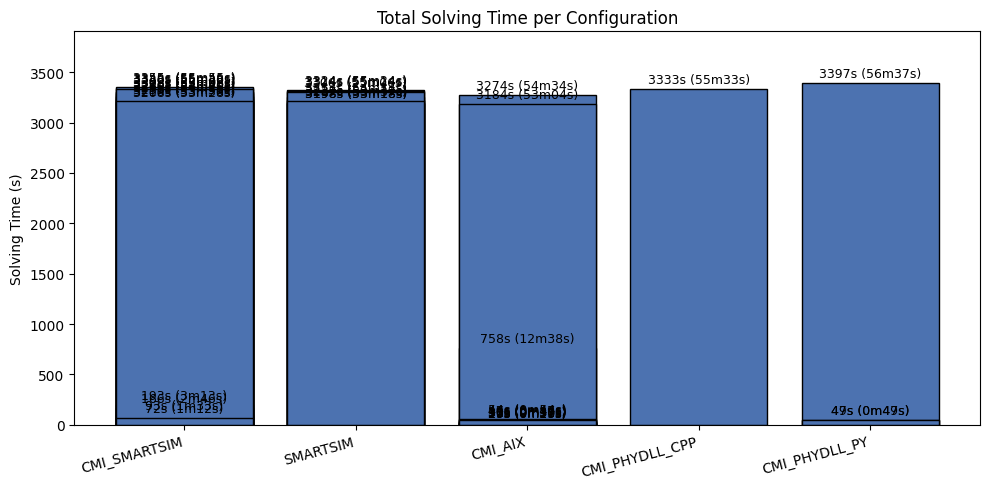

In [2]:
import matplotlib.pyplot as plt
import numpy as np

valid = df[df['SolvingTime_s'] > 0].copy()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(valid['RunName'], valid['SolvingTime_s'], color='#4C72B0', edgecolor='black')
for bar, val in zip(bars, valid['SolvingTime_s']):
    h = int(val // 3600)
    m = int((val % 3600) // 60)
    s = int(val % 60)
    label = f"{val}s ({h}h{m:02d}m{s:02d}s)" if h > 0 else f"{val}s ({m}m{s:02d}s)"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            label, ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Solving Time (s)')
ax.set_title('Total Solving Time per Configuration')
ax.set_ylim(0, valid['SolvingTime_s'].max() * 1.15)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Network Traffic (IB0)

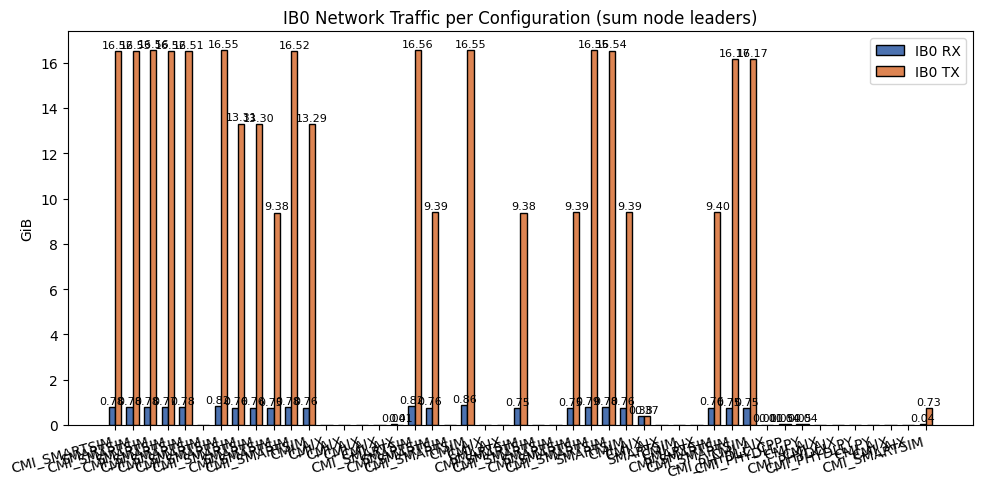

In [3]:
net = df.copy()
x = np.arange(len(net))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w / 2, net['IB0_RX_GiB'], w, label='IB0 RX', color='#4C72B0', edgecolor='black')
b2 = ax.bar(x + w / 2, net['IB0_TX_GiB'], w, label='IB0 TX', color='#DD8452', edgecolor='black')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('GiB')
ax.set_title('IB0 Network Traffic per Configuration (sum node leaders)')
ax.set_xticks(x)
ax.set_xticklabels(net['RunName'], rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Score-P Phase Breakdown

Phase breakdown of execution time across the setup, computation, ML inference, and teardown stages, obtained from Score-P profile files.

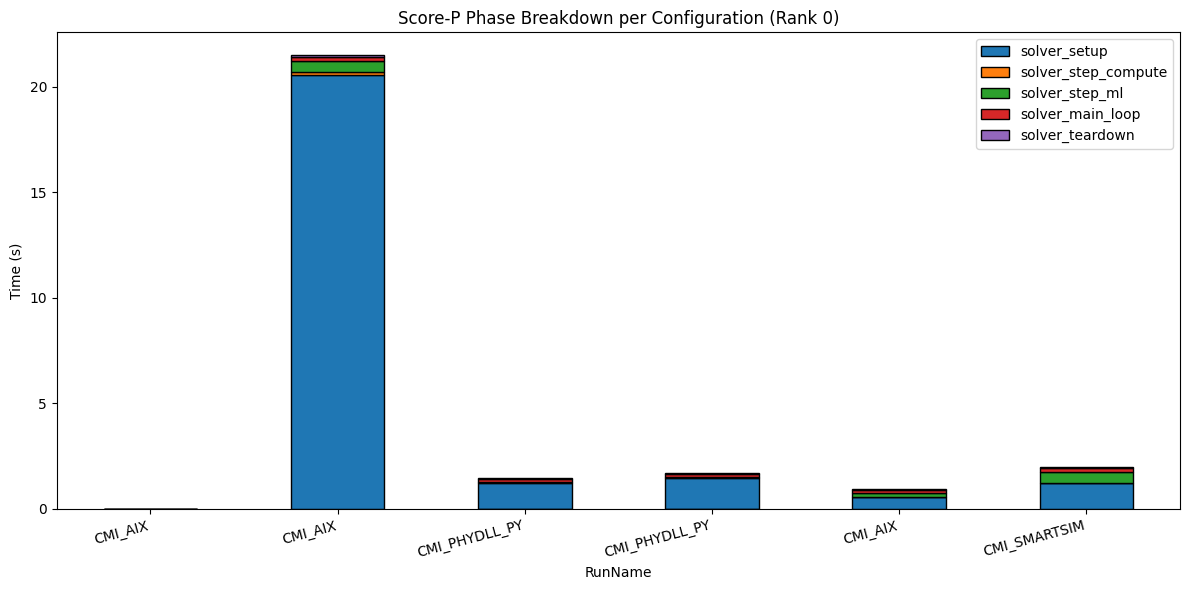

In [4]:
import subprocess
from pathlib import Path

def get_scorep_phases(provider, job_id):
    candidates = [
        Path(f"scorep_{provider}_{job_id}_rank_0/profile.cubex"),
        Path(f"scorep_{provider}_{job_id}/profile.cubex")
    ]
    cubex_file = None
    for c in candidates:
        if c.exists():
            cubex_file = c
            break
    if not cubex_file:
        return {}
    
    try:
        # Use absolute path to scorep-score
        scorep_bin = "/cvmfs/software.hpc.rwth.de/Linux/RH9/x86_64/intel/sapphirerapids/software/Score-P/8.4-gompi-2022a/bin/scorep-score"
        cmd = f"{scorep_bin} -r {cubex_file}"
        output = subprocess.check_output(cmd, shell=True, text=True)
        phases = {}
        for line in output.strip().split("\n"):
            parts = line.split()
            if len(parts) >= 6:
                region = parts[-1]
                try:
                    time_s = float(parts[-4])
                    phases[region] = time_s
                except ValueError:
                    continue
        return phases
    except Exception as e:
        print(f"Error reading Score-P profile for {provider} (Job {job_id}): {e}")
        return {}

regions_of_interest = [
    'solver_setup',
    'solver_step_compute',
    'solver_step_ml',
    'solver_main_loop',
    'solver_teardown'
]

profile_data = []
for index, row in df.iterrows():
    provider = row['RunName'].split('_')[1] if 'CMI_' in row['RunName'] else 'SMARTSIM'
    phases = get_scorep_phases(provider, row['JobID'])
    if phases:
        entry = {'RunName': row['RunName']}
        for r in regions_of_interest:
            entry[r] = phases.get(r, 0.0)
        profile_data.append(entry)

df_profile = pd.DataFrame(profile_data)
if not df_profile.empty:
    df_profile.set_index('RunName', inplace=True)
    ax = df_profile.plot(kind='bar', stacked=True, figsize=(12, 6), edgecolor='black')
    ax.set_ylabel('Time (s)')
    ax.set_title('Score-P Phase Breakdown per Configuration (Rank 0)')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No Score-P profile directories found.")

## Logical Tensors Size vs. Actual Network Traffic

Comparison between the logical size of tensors transferred (from ML coupling logs) vs. the actual bytes transmitted over the network.

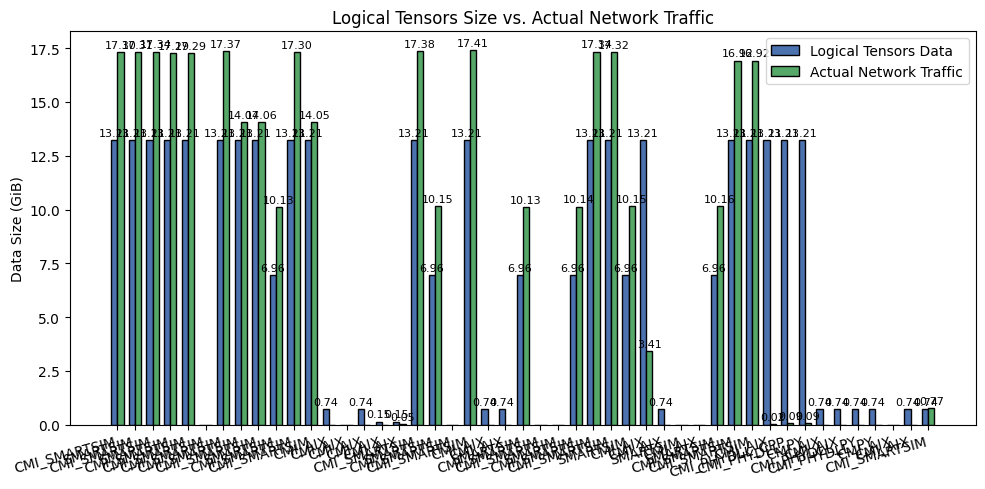

In [5]:
df_bytes = df.copy()
df_bytes['Logical_GiB'] = df_bytes['ML_Input_GiB'] + df_bytes['ML_Output_GiB']
df_bytes['Actual_GiB'] = df_bytes['IB0_RX_GiB'] + df_bytes['IB0_TX_GiB'] + df_bytes['LO_RX_GiB'] + df_bytes['LO_TX_GiB']

x = np.arange(len(df_bytes))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w / 2, df_bytes['Logical_GiB'], w, label='Logical Tensors Data', color='#4C72B0', edgecolor='black')
b2 = ax.bar(x + w / 2, df_bytes['Actual_GiB'], w, label='Actual Network Traffic', color='#55A868', edgecolor='black')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Data Size (GiB)')
ax.set_title('Logical Tensors Size vs. Actual Network Traffic')
ax.set_xticks(x)
ax.set_xticklabels(df_bytes['RunName'], rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## GPU Memory Metrics

GPU memory utilization parsed from redis_gpu.log monitoring if GPU execution was enabled.

In [6]:
def parse_gpu_log(provider, job_id):
    path = Path(f"scorep_{provider}_{job_id}/redis_gpu.log")
    if not path.exists():
        path = Path(f"scorep_{provider}_{job_id}_rank_0/redis_gpu.log")
    if not path.exists():
        return None
    
    content = path.read_text(encoding='utf-8', errors='replace').strip()
    if not content:
        return "Empty GPU Log (CPU execution)"
    
    max_fb = 0
    max_usr = 0
    lines_parsed = 0
    for line in content.split('\n'):
        if line.startswith('#') or not line.strip():
            continue
        parts = line.split()
        if len(parts) >= 6:
            try:
                usr = int(parts[1])
                fb = int(parts[5])
                max_fb = max(max_fb, fb)
                max_usr = max(max_usr, usr)
                lines_parsed += 1
            except ValueError:
                continue
    if lines_parsed == 0:
        return "Log format unparseable or idle"
    return f"Peak GPU Memory: {max_fb} MB, Peak GPU Util: {max_usr}%"

gpu_results = {}
for index, row in df.iterrows():
    provider = row['RunName'].split('_')[1] if 'CMI_' in row['RunName'] else 'SMARTSIM'
    res = parse_gpu_log(provider, row['JobID'])
    if res:
        gpu_results[row['RunName']] = res

for run, res in gpu_results.items():
    print(f"{run}: {res}")

CMI_SMARTSIM: Empty GPU Log (CPU execution)
